# Day 2 — Activations, Forward Propagation & Loss

## Objective

In this notebook, we explore the fundamental concepts needed to understand how neural networks make predictions.

We will:
- Understand why activation functions are necessary.
- Explore common activation functions.
- Visualize ReLU, Sigmoid, and Tanh.
- Identify the correct output activation and loss function for the cardiovascular disease classification task.
- Perform a forward pass through a small neural network using NumPy.
- Calculate Binary Cross-Entropy loss.

## Dataset

For this task, we use the previously cleaned cardiovascular disease dataset:

cardio_cleaned

The target variable is cardio, which represents whether the patient has cardiovascular disease.

- 0 → No cardiovascular disease
- 1 → Cardiovascular disease

The dataset has already been cleaned, so no additional cleaning is required for this task.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cardio_cleaned.csv")

In [11]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("Target distribution:")
print(df["cardio"].value_counts())

Dataset shape: (68742, 13)
Columns:
['id', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']
Target distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64


## 2.1 ReLU

ReLU (Rectified Linear Unit) is one of the most commonly used activation functions in neural networks.

It is defined as:

ReLU(x) = max(0, x)

This means:

- Negative values are converted to 0.
- Positive values remain unchanged.

ReLU introduces non-linearity into the network and is commonly used in hidden layers.

In [12]:
def relu(x):
    return np.maximum(0, x)

In [13]:
x_test = np.array([-3, -1, 0, 1, 3])

print("Input:", x_test)
print("ReLU:", relu(x_test))

Input: [-3 -1  0  1  3]
ReLU: [0 0 0 1 3]


## 2.2 Sigmoid

The Sigmoid activation function is defined as:

Sigmoid(x) = 1 / (1 + e^(-x))

It maps any input value to a value between 0 and 1.

Because its output can be interpreted as a probability, Sigmoid is commonly used in the output layer for binary classification.

In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print("Input:", x_test)
print("Sigmoid:", sigmoid(x_test))    

Input: [-3 -1  0  1  3]
Sigmoid: [0.04742587 0.26894142 0.5        0.73105858 0.95257413]


## 2.3 Tanh

The Tanh activation function maps input values to the range from -1 to 1.

It is zero-centered, meaning that its output can contain both negative and positive values.

Tanh can be used in hidden layers in some neural networks, although ReLU is generally the default choice.

In [15]:
def tanh(x):
    return np.tanh(x)
print("Input:", x_test)
print("Tanh:", tanh(x_test))    

Input: [-3 -1  0  1  3]
Tanh: [-0.99505475 -0.76159416  0.          0.76159416  0.99505475]


## 3. Visualizing Activation Functions

We will visualize ReLU, Sigmoid, and Tanh over the same range of input values.

This allows us to compare how each activation function transforms input values.

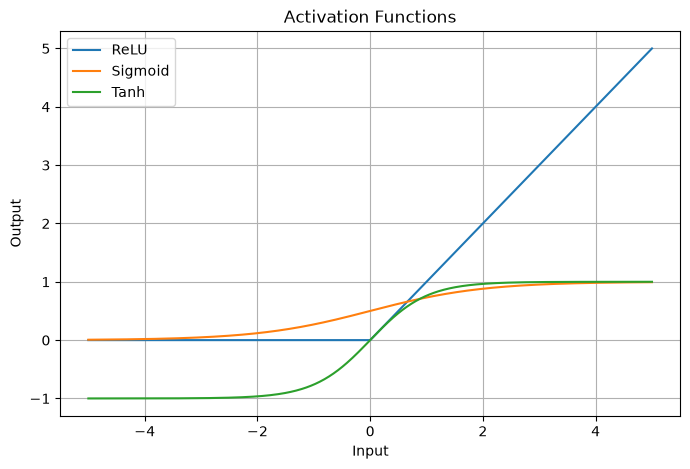

In [16]:
x = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 5))

plt.plot(x, relu(x), label="ReLU")
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- **ReLU:** Outputs 0 for negative inputs. For positive inputs, the output increases linearly with the input.
- **Sigmoid:** Maps all inputs to values between 0 and 1. At x = 0, the output is 0.5.
- **Tanh:** Maps all inputs to values between -1 and 1 and is centered around zero.

Therefore, ReLU is commonly used in hidden layers, while Sigmoid is suitable for the output layer of binary classification problems.

##  Choosing the Output Activation and Loss Function

The target variable in our cardiovascular disease dataset is cardio.

It contains two classes:

- 0 → No cardiovascular disease
- 1 → Cardiovascular disease

Therefore, this is a **binary classification** problem.

### Output Activation: Sigmoid

Since this is a binary classification problem, the output layer will use the **Sigmoid** activation function.

Sigmoid maps the output to a value between 0 and 1, which can be interpreted as the probability that a patient belongs to class 1 (cardiovascular disease).

Therefore:

**Output Activation → Sigmoid**

### Loss Function: Binary Cross-Entropy

For binary classification with a Sigmoid output, we use **Binary Cross-Entropy (BCE)**.

Binary Cross-Entropy measures the difference between the true binary label and the predicted probability.

The formula is:

BCE = -[y log(p) + (1-y) log(1-p)]

where:

- y is the true label.
- p is the predicted probability.

Therefore:

**Loss Function → Binary Cross-Entropy**



### Final Choice

| Component | Choice | Reason |
|---|---|---|
| Problem Type | Binary Classification | The target has two classes |
| Hidden Layer Activation | ReLU | Common and effective for hidden layers |
| Output Activation | Sigmoid | Produces a probability between 0 and 1 |
| Loss Function | Binary Cross-Entropy | Suitable for binary classification with Sigmoid |

## 6. Forward Propagation

Forward propagation is the process of passing input data through the neural network to produce a prediction.

For this demonstration, we use a small neural network with:

- 3 input features
- 2 neurons in the hidden layer
- 1 output neuron

Architecture:

Input → Dense(2, ReLU) → Dense(1, Sigmoid)

In [17]:

X = np.array([[0.5, 1.0, 0.2]])

# Hidden layer weights
W1 = np.array([
    [0.2, -0.4],
    [0.7,  0.5],
    [-0.3, 0.8]
])


b1 = np.array([[0.1, 0.2]])


W2 = np.array([
    [0.6],
    [-0.5]
])


b2 = np.array([[0.1]])

In [18]:
Z1 = np.dot(X, W1) + b1

print("Z1:")
print(Z1)

Z1:
[[0.84 0.66]]


In [19]:
A1 = relu(Z1)

print("A1 after ReLU:")
print(A1)

A1 after ReLU:
[[0.84 0.66]]


In [20]:
Z2 = np.dot(A1, W2) + b2

print("Z2:")
print(Z2)

Z2:
[[0.274]]


In [21]:
A2 = sigmoid(Z2)

print("Final prediction probability:")
print(A2)

Final prediction probability:
[[0.56807463]]


In [22]:
prediction = (A2 >= 0.5).astype(int)

print("Predicted probability:", A2[0, 0])
print("Predicted class:", prediction[0, 0])

Predicted probability: 0.5680746343565884
Predicted class: 1


### Forward Pass Result

The sample was passed through the neural network using forward propagation.

The hidden layer used **ReLU**, while the output layer used **Sigmoid**.

The final calculations produced:

- Z1 = [[0.84, 0.66]]
- A1 = [[0.84, 0.66]]
- Z2 = [[0.274]]
- A2 = [[0.5681]]

The final predicted probability was approximately **56.8%**.

Using a threshold of 0.5, the predicted class is:

**Class 1 — Cardiovascular disease**

In [23]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-7
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    return -(y_true * np.log(y_pred) + 
             (1 - y_true) * np.log(1 - y_pred))

In [24]:
y_true = np.array([[1]])

loss = binary_cross_entropy(y_true, A2)

print("True label:", y_true[0, 0])
print("Predicted probability:", A2[0, 0])
print("Binary Cross-Entropy Loss:", loss[0, 0])

True label: 1
Predicted probability: 0.5680746343565884
Binary Cross-Entropy Loss: 0.5655024703778939


### Loss Result

The true label is 1, while the model predicted a probability of approximately 0.5681.

Since the probability is greater than 0.5, the predicted class is 1.

The Binary Cross-Entropy loss is approximately **0.5655**.

The prediction is correct, but the probability is not very close to 1, so the loss is not close to zero.

In general, a lower loss indicates that the predicted probability is closer to the true label.